In [1]:
import pandas as pd
import glob
import os

# 1. Definimos las columnas necesarias para el filtrado (Grupo 6: Usar y Tirar) [cite: 204-206]
columnas_limpieza = ['CANCELLED', 'DIVERTED']

# 2. Tu lista completa de 40 columnas para el TFG [cite: 280-296]
columnas_tfg = [
    'TAIL_NUMBER', 'FLIGHTDATE', 'CRSDEPTIME', 'CRSARRTIME', 'ARRDELAY', 'ARRDEL15',
    'MONTH', 'QUARTER', 'DAYOFWEEK', 'REPORTING_AIRLINE', 'ORIGINAIRPORTID', 
    'DESTAIRPORTID', 'DEPTIMEBLK', 'ARRTIMEBLK', 'CRSELAPSEDTIME', 'DISTANCE', 
    'IATA_CODE_REPORTING_AIRLINE', 'ORIGIN', 'DEST', 'ORIGINCITYNAME', 
    'DESTCITYNAME', 'ORIGINSTATENAME', 'DESTSTATENAME', 'DEPTIME', 'DEPDELAY', 
    'DEPDEL15', 'TAXIOUT', 'WHEELSOFF', 'WHEELSON', 'TAXIIN', 'ARRTIME', 
    'ACTUALELAPSEDTIME', 'AIRTIME', 'CARRIERDELAY', 'WEATHERDELAY', 'NASDELAY', 
    'SECURITYDELAY', 'LATEAIRCRAFTDELAY'
]

# Unimos ambas listas para la carga inicial
todas_las_columnas = columnas_tfg + columnas_limpieza

# 3. Ruta y búsqueda de archivos
ruta_carpeta = '/Users/manuelgonzalez/Documents/Datos crudos TFG' 
archivos_csv = glob.glob(os.path.join(ruta_carpeta, "*.csv"))

df_lista = []

for f in archivos_csv:
    print(f"Procesando: {os.path.basename(f)}...")
    # Cargamos el archivo completo
    temp_df = pd.read_csv(f, low_memory=False)
    
    # Normalizamos nombres a MAYÚSCULAS para evitar errores de lectura [cite: 272]
    temp_df.columns = temp_df.columns.str.strip().str.upper()
    
    # --- FILTRADO DE FILAS (Antes de quitar las columnas) [cite: 274, 276] ---
    # Solo nos quedamos con vuelos que NO fueron cancelados ni desviados
    if 'CANCELLED' in temp_df.columns and 'DIVERTED' in temp_df.columns:
        temp_df = temp_df[(temp_df['CANCELLED'] == 0) & (temp_df['DIVERTED'] == 0)]
    
    # --- SELECCIÓN DE COLUMNAS ---
    # Filtramos el DataFrame para que solo tenga las columnas de tu lista TFG que existan en el archivo
    temp_df = temp_df[[c for c in columnas_tfg if c in temp_df.columns]]
    
    df_lista.append(temp_df)

# 4. Concatenación final de los 6 meses
df_total = pd.concat(df_lista, ignore_index=True)

print(f"\n✅ PASO 1 COMPLETADO")
print(f"Dataset total filtrado y limpio: {df_total.shape[0]} filas y {df_total.shape[1]} columnas.")

Procesando: Datos_de_Marzo.csv...
Procesando: Datos_de_Mayo.csv...
Procesando: Datos_de_Abril.csv...
Procesando: Datos_de_Junio.csv...
Procesando: Datos_de_Febrero.csv...
Procesando: Datos_de_Enero.csv...

✅ PASO 1 COMPLETADO
Dataset total filtrado y limpio: 3403465 filas y 38 columnas.


In [2]:
import pandas as pd

# 1. Transformamos la fecha a formato real [cite: 94]
df_total['FLIGHTDATE'] = pd.to_datetime(df_total['FLIGHTDATE'])

# 2. Lista de columnas que son horas en formato 'hhmm' [cite: 97]
columnas_de_hora = ['CRSDEPTIME', 'CRSARRTIME', 'DEPTIME', 'ARRTIME', 'WHEELSOFF', 'WHEELSON']

print("Iniciando conversión de formatos de hora...")

for col in columnas_de_hora:
    # Aplicamos tu lógica: fillna(0) -> int -> str -> zfill(4) [cite: 101-104]
    # Luego convertimos a datetime y extraemos solo la hora [cite: 105-109]
    df_total[f'{col}_FORMATO'] = pd.to_datetime(
        df_total[col].fillna(0).astype(int).astype(str).str.zfill(4), 
        format='%H%M', 
        errors='coerce' 
    ).dt.time

# 3. Borramos las columnas originales para que no te "pete" la RAM [cite: 118-120]
df_total = df_total.drop(columns=columnas_de_hora)

print("✅ PASO 2 COMPLETADO: Todas las variables de tiempo están en formato operativo.")

Iniciando conversión de formatos de hora...
✅ PASO 2 COMPLETADO: Todas las variables de tiempo están en formato operativo.


In [3]:
import pandas as pd

print("Creando columna 'FULL_DATETIME_DEP' (Fecha + Hora combinadas)...")

# 1. Combinamos la Fecha y la Hora en un solo objeto datetime [cite: 176-178]
# Usamos .astype(str) para concatenar y pd.to_datetime para convertir
df_total['FULL_DATETIME_DEP'] = pd.to_datetime(
    df_total['FLIGHTDATE'].dt.date.astype(str) + ' ' + 
    df_total['CRSDEPTIME_FORMATO'].astype(str),
    errors='coerce'
)

# 2. La ordenación ahora es mucho más limpia
print("Aplicando ordenación cronológica maestra...")
df_total = df_total.sort_values(by=[
    'TAIL_NUMBER',        # Primero agrupamos por avión
    'FULL_DATETIME_DEP'   # Luego ordenamos toda su historia de golpe
]).reset_index(drop=True)

# 3. Movemos la columna al principio para que sea fácil de ver
cols = ['TAIL_NUMBER', 'FLIGHTDATE', 'FULL_DATETIME_DEP'] + \
       [c for c in df_total.columns if c not in ['TAIL_NUMBER', 'FLIGHTDATE', 'FULL_DATETIME_DEP']]
df_total = df_total[cols]

print("✅ PASO 3.1 COMPLETADO: Tienes una línea de tiempo única por avión.")

Creando columna 'FULL_DATETIME_DEP' (Fecha + Hora combinadas)...
Aplicando ordenación cronológica maestra...
✅ PASO 3.1 COMPLETADO: Tienes una línea de tiempo única por avión.


In [4]:
# 1. La ordenación que "entiende" el modelo: Avión primero, luego su historia completa 
print("Ordenando 3.4 millones de filas para la lógica del modelo...")
df_total = df_total.sort_values(by=[
    'TAIL_NUMBER',        # Agrupamos toda la vida del avión
    'FULL_DATETIME_DEP'   # Ordenamos sus vuelos desde enero hasta junio
]).reset_index(drop=True)

print("✅ Tabla ordenada por continuidad de aeronave.")

Ordenando 3.4 millones de filas para la lógica del modelo...
✅ Tabla ordenada por continuidad de aeronave.


In [5]:
import numpy as np

print("Calculando variables de ingeniería del dato...")

# --- 1. Variable: Retraso Vuelo Anterior 
# "Miramos" el retraso de llegada de la fila de arriba
df_total['RETRASO_VUELO_ANTERIOR'] = df_total['ARRDELAY'].shift(1)

# --- 2. Filtros de Seguridad [cite: 219, 277]
# Solo pasamos el testigo si es el MISMO avión. 
mismo_avion = (df_total['TAIL_NUMBER'] == df_total['TAIL_NUMBER'].shift(1))
# OJO: Para tu tesis de "Efecto Dominó diario", mantenemos el filtro de mismo día [cite: 219]
mismo_dia = (df_total['FLIGHTDATE'] == df_total['FLIGHTDATE'].shift(1))

# Si cambia de avión o es el primer vuelo del día, el retraso anterior es NaN (nulo) 
df_total['RETRASO_VUELO_ANTERIOR'] = df_total['RETRASO_VUELO_ANTERIOR'].where(mismo_avion & mismo_dia, np.nan)

# --- 3. Variable: Bola de Nieve (Retraso Acumulado) [cite: 236-243]
# Sumamos los retrasos que lleva el avión en el día y lo desplazamos para que no sea trampa
retraso_acum_dia = df_total.groupby(['TAIL_NUMBER', 'FLIGHTDATE'])['ARRDELAY'].cumsum()
df_total['FEAT_RETRASO_ACUMULADO'] = retraso_acum_dia.shift(1).where(mismo_avion & mismo_dia, np.nan)

# --- 4. Variable: Margen Operativo Real (Tu Pista de Oro) [cite: 291-297]
# Primero calculamos el "colchón" programado en minutos [cite: 271-273]
# (Salida programada actual - Llegada programada anterior)
hora_llegada_anterior = pd.to_datetime(
    df_total['FLIGHTDATE'].dt.date.astype(str) + ' ' + df_total['CRSARRTIME_FORMATO'].shift(1).astype(str),
    errors='coerce'
)
df_total['TIEMPO_TIERRA_PROG'] = (df_total['FULL_DATETIME_DEP'] - hora_llegada_anterior).dt.total_seconds() / 60
df_total['TIEMPO_TIERRA_PROG'] = df_total['TIEMPO_TIERRA_PROG'].where(mismo_avion & mismo_dia, np.nan)

# La fórmula maestra[cite: 297]:
# $MARGEN\_OPERATIVO\_REAL = TIEMPO\_TIERRA\_PROG - RETRASO\_VUELO\_ANTERIOR$
df_total['MARGEN_OPERATIVO_REAL'] = df_total['TIEMPO_TIERRA_PROG'] - df_total['RETRASO_VUELO_ANTERIOR']

print("✅ Variables de ingeniería completadas.")

Calculando variables de ingeniería del dato...
✅ Variables de ingeniería completadas.


In [32]:
# Rellenamos los huecos del 'vuelo madrugador'
columnas_estrategicas = [
    'RETRASO_VUELO_ANTERIOR', 'FEAT_RETRASO_ACUMULADO', 
    'MARGEN_OPERATIVO_REAL', 'TIEMPO_TIERRA_PROG'
]

# Sustituimos los nulos por 0 porque no hay herencia de retrasos
for col in columnas_estrategicas:
    df_total[col] = df_total[col].fillna(0)

print("✅ Hemorragia cortada. Ahora tus variables estratégicas tienen 0% de nulos.")

✅ Hemorragia cortada. Ahora tus variables estratégicas tienen 0% de nulos.


In [33]:
import pandas as pd

# 1. Definimos la lista de variables que tienes ahora mismo
variables_tfg = [
    'MONTH', 'DAYOFWEEK', 'REPORTING_AIRLINE', 'DEPTIMEBLK', 'ORIGIN', 'DEST', 
    'DEPDELAY', 'TAXIOUT', 'TAXIIN', 'ARRDELAY', 'ARRDEL15', 'RETRASO_VUELO_ANTERIOR', 
    'FEAT_RETRASO_ACUMULADO', 'TIEMPO_TIERRA_PROG', 'MARGEN_OPERATIVO_REAL', 
    'Rango_de_Retraso', 'ES_FESTIVO', 'VUELOS_AEROPUERTO_DIA', 'FRANJA_HORARIA', 
    'RECUPERACION_MINUTOS', 'MARGEN_CATEGORIA', 'TIPO_AEROPUERTO', 'ESTACION',
    'CARRIERDELAY', 'WEATHERDELAY', 'NASDELAY', 'SECURITYDELAY', 'LATEAIRCRAFTDELAY'
]

# 2. Calculamos nulos sobre df_total (asegurándonos de que las columnas existen)
cols_presentes = [c for c in variables_tfg if c in df_total.columns]
nulos_conteo = df_total[cols_presentes].isnull().sum()
nulos_porcentaje = (nulos_conteo / len(df_total)) * 100

# 3. Creamos la tabla final para el documento
tabla_calidad_post = pd.DataFrame({
    'Variable': nulos_conteo.index,
    'Valores Nulos': nulos_conteo.values,
    'Porcentaje de Nulos (%)': nulos_porcentaje.round(4).astype(str) + ' %'
})

# 4. Ordenamos para que lo más "feo" (las causas de retraso) salga arriba
print("📊 TABLA: INTEGRIDAD DEL DATASET TRAS UNIÓN Y PROCESAMIENTO")
print("-" * 70)
display(tabla_calidad_post.sort_values(by='Valores Nulos', ascending=False))

📊 TABLA: INTEGRIDAD DEL DATASET TRAS UNIÓN Y PROCESAMIENTO
----------------------------------------------------------------------


,Variable,Valores Nulos,Porcentaje de Nulos (%)
MONTH,MONTH,0,0.0 %
DAYOFWEEK,DAYOFWEEK,0,0.0 %
SECURITYDELAY,SECURITYDELAY,0,0.0 %
NASDELAY,NASDELAY,0,0.0 %
WEATHERDELAY,WEATHERDELAY,0,0.0 %
CARRIERDELAY,CARRIERDELAY,0,0.0 %
ESTACION,ESTACION,0,0.0 %
TIPO_AEROPUERTO,TIPO_AEROPUERTO,0,0.0 %
MARGEN_CATEGORIA,MARGEN_CATEGORIA,0,0.0 %
RECUPERACION_MINUTOS,RECUPERACION_MINUTOS,0,0.0 %


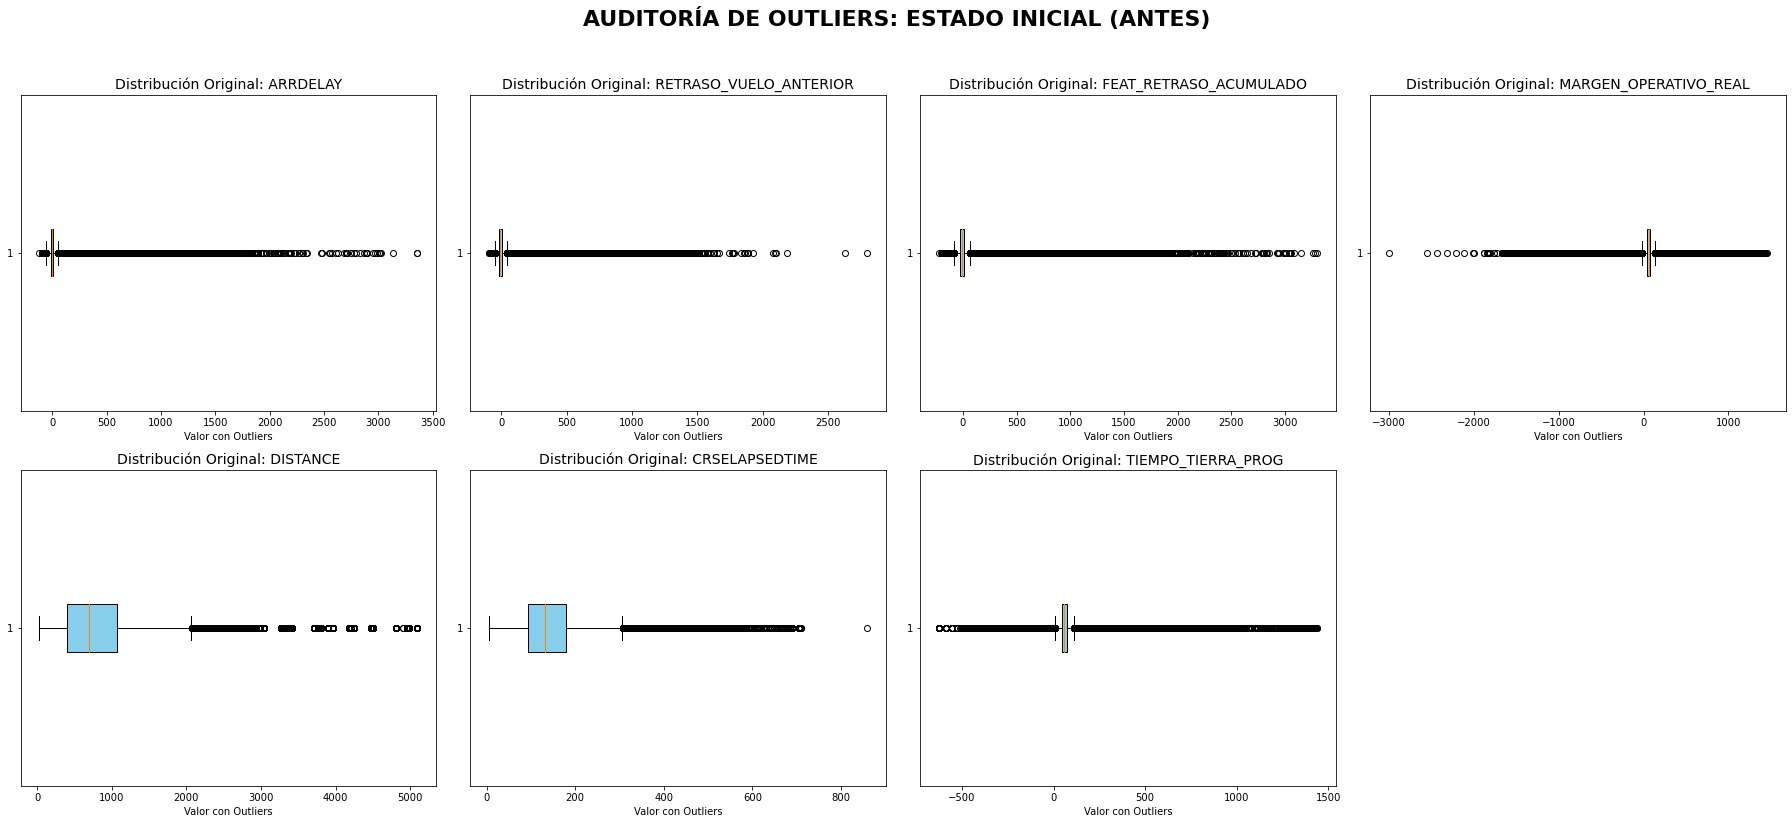

In [7]:
import matplotlib.pyplot as plt

# 1. Definimos las 7 variables exactas para la auditoría
cols_7 = ['ARRDELAY', 'RETRASO_VUELO_ANTERIOR', 'FEAT_RETRASO_ACUMULADO', 
          'MARGEN_OPERATIVO_REAL', 'DISTANCE', 'CRSELAPSEDTIME', 'TIEMPO_TIERRA_PROG']

# 2. Creamos la figura (2 filas: 4 arriba y 3 abajo)
fig = plt.figure(figsize=(25, 12))
fig.suptitle('AUDITORÍA DE OUTLIERS: ESTADO INICIAL (ANTES)', fontsize=22, fontweight='bold')

for i, col in enumerate(cols_7):
    ax = fig.add_subplot(2, 4, i + 1) # Creamos cuadrícula de 2x4
    ax.boxplot(df_total[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor="skyblue"))
    ax.set_title(f'Distribución Original: {col}', fontsize=14)
    ax.set_xlabel('Valor con Outliers')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [8]:
# 1. Aplicamos el Super-Filtro de integridad operativa
df_total = df_total[
    (df_total['ARRDELAY'] < 180) & (df_total['ARRDELAY'] > -60) &            # Vuelo actual razonable
    (df_total['DISTANCE'] < 2500) & (df_total['CRSELAPSEDTIME'] < 360) &    # Solo corto/medio radio
    (df_total['RETRASO_VUELO_ANTERIOR'] < 180) &                            # La herencia debe ser limpia
    (df_total['FEAT_RETRASO_ACUMULADO'] < 300) &                            # Bola de nieve lógica
    (df_total['TIEMPO_TIERRA_PROG'] >= 0) & (df_total['TIEMPO_TIERRA_PROG'] < 500) # Escalas humanas
].copy()

# 2. Mostramos el resumen numérico (Count, Mean, Std, Min, Max...)
print("📊 RESUMEN ESTADÍSTICO POST-QUEMA (Para tu memoria del TFG):")
display(df_total[cols_7].describe())

print(f"\n🔥 Filas restantes tras la limpieza: {df_total.shape[0]}")

📊 RESUMEN ESTADÍSTICO POST-QUEMA (Para tu memoria del TFG):


,ARRDELAY,RETRASO_VUELO_ANTERIOR,FEAT_RETRASO_ACUMULADO,MARGEN_OPERATIVO_REAL,DISTANCE,CRSELAPSEDTIME,TIEMPO_TIERRA_PROG
count,2.354820e+06,2.354820e+06,2.354820e+06,2.354820e+06,2.354820e+06,2.354820e+06,2.354820e+06
mean,3.256537e+00,3.202746e-01,-4.972644e+00,6.573275e+01,7.595340e+02,1.373526e+02,6.605303e+01
std,3.048662e+01,2.775148e+01,5.087714e+01,5.383334e+01,4.997973e+02,6.102344e+01,4.745009e+01
min,-5.900000e+01,-8.900000e+01,-2.220000e+02,-1.750000e+02,3.100000e+01,2.200000e+01,0.000000e+00
25%,-1.500000e+01,-1.500000e+01,-3.100000e+01,4.400000e+01,3.830000e+02,9.000000e+01,4.500000e+01
50%,-5.000000e+00,-7.000000e+00,-1.400000e+01,6.100000e+01,6.410000e+02,1.250000e+02,5.500000e+01
75%,1.000000e+01,7.000000e+00,5.000000e+00,7.900000e+01,1.010000e+03,1.700000e+02,7.000000e+01
max,1.790000e+02,1.790000e+02,2.990000e+02,5.400000e+02,2.498000e+03,3.590000e+02,4.990000e+02



🔥 Filas restantes tras la limpieza: 2354820


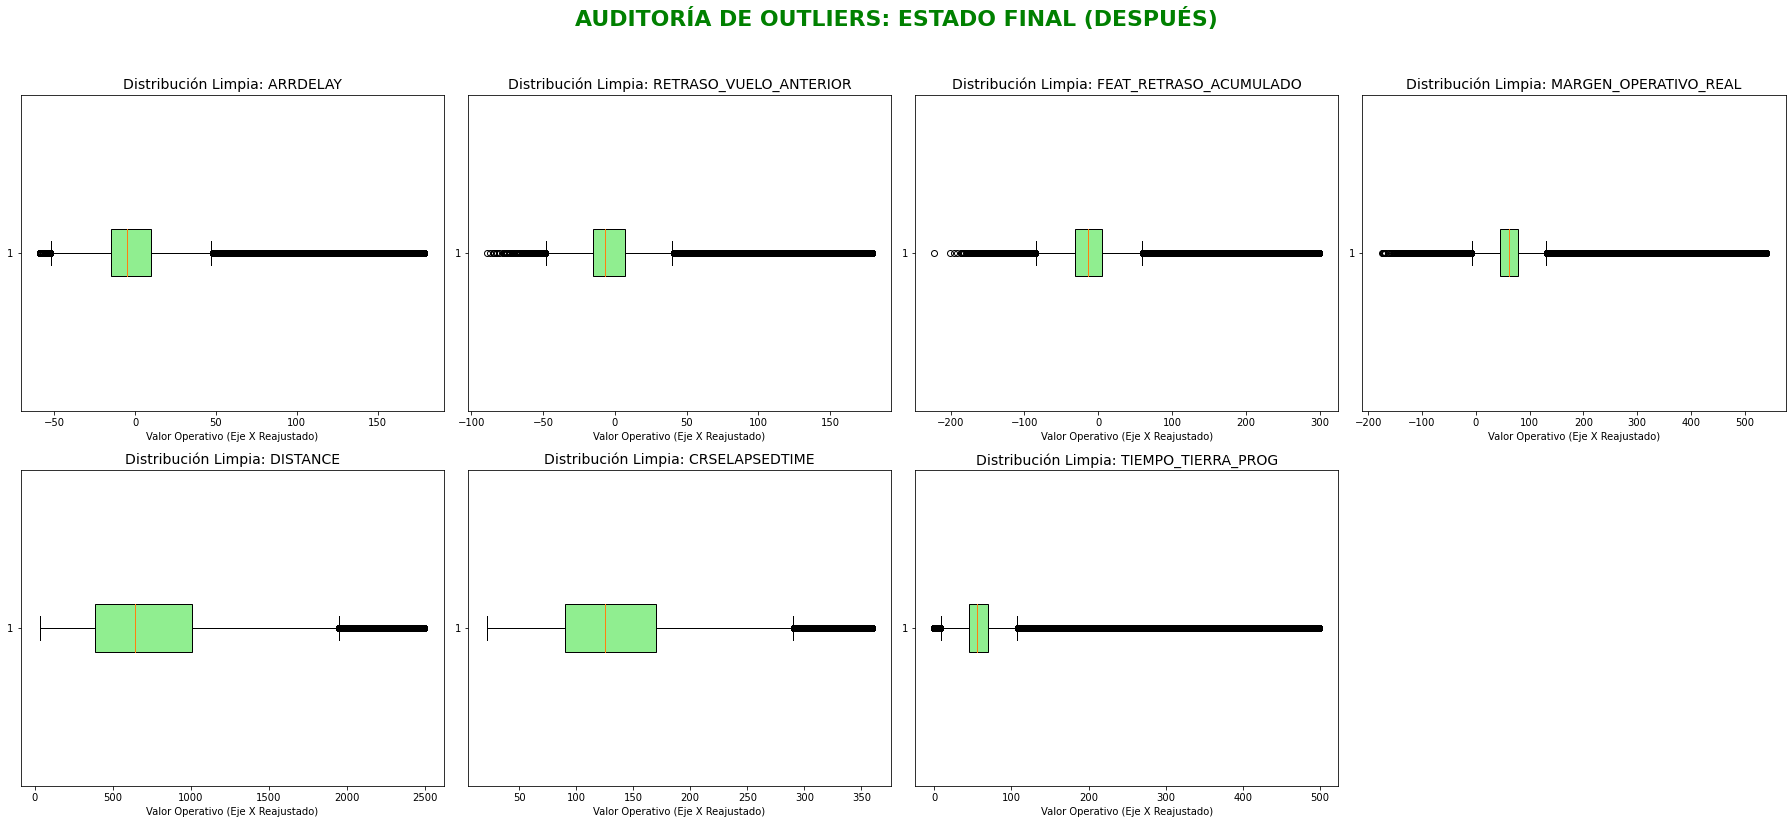

In [9]:
# Generamos la misma estructura de 4 y 3 pero con el df_total ya filtrado
fig = plt.figure(figsize=(25, 12))
fig.suptitle('AUDITORÍA DE OUTLIERS: ESTADO FINAL (DESPUÉS)', fontsize=22, fontweight='bold', color='green')

for i, col in enumerate(cols_7):
    ax = fig.add_subplot(2, 4, i + 1)
    # Al estar los datos limpios, Matplotlib ajustará la escala automáticamente
    ax.boxplot(df_total[col].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor="lightgreen"))
    ax.set_title(f'Distribución Limpia: {col}', fontsize=14)
    ax.set_xlabel('Valor Operativo (Eje X Reajustado)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [10]:
import pandas as pd
import numpy as np

print("Iniciando PASO 6: Diana y Contexto...")

# --- 1. Creación de la Diana (Rango_de_Retraso) [cite: 471-489] ---
# Definimos los cortes: <0 (adelantado), 0-15 (a tiempo), 15-45 (pequeño), 45-120 (medio), >120 (grave)
bins = [-float('inf'), 0, 15, 45, 120, 180.1]
labels = [0, 1, 2, 3, 4] # Mapeo directo a números para el modelo [cite: 485-489]

df_total['Rango_de_Retraso'] = pd.cut(
    df_total['ARRDELAY'], 
    bins=bins, 
    labels=labels, 
    right=False
).astype(int)

# --- 2. Pista de Contexto: Festivos 2024 (Enero-Junio)  ---
# He incluido los festivos reales de tu semestre
festivos_semestre = [
    '2024-01-01', '2024-01-15', '2024-02-19', '2024-05-27', '2024-06-19'
]
festivos_dates = pd.to_datetime(festivos_semestre).date
df_total['ES_FESTIVO'] = df_total['FLIGHTDATE'].dt.date.isin(festivos_dates).astype(int)

# --- 3. Pista de Contexto: Congestión del Aeropuerto  ---
# Contamos cuántos vuelos salen de cada aeropuerto cada día
conteo_congestion = df_total.groupby(['FLIGHTDATE', 'ORIGINAIRPORTID']).size().reset_index(name='VUELOS_AEROPUERTO_DIA')
df_total = pd.merge(df_total, conteo_congestion, on=['FLIGHTDATE', 'ORIGINAIRPORTID'], how='left')

print("✅ PASO 6 COMPLETADO: Diana multiclase y variables de contexto creadas.")

Iniciando PASO 6: Diana y Contexto...
✅ PASO 6 COMPLETADO: Diana multiclase y variables de contexto creadas.


In [11]:
# Lista negra de variables que sobran por redundancia, ruido o leakage
variables_basura = [
    'QUARTER', 'IATA_CODE_REPORTING_AIRLINE', 
    'ORIGINAIRPORTID', 'DESTAIRPORTID',
    'ORIGINCITYNAME', 'DESTCITYNAME', 
    'ORIGINSTATENAME', 'DESTSTATENAME', 'DEPDEL15', 'ARRTIMEBLK', 'ACTUALELAPSEDTIME',
     'CRSARRTIME_FORMATO', 
    'DEPTIME_FORMATO', 'ARRTIME_FORMATO', 
    'WHEELSOFF_FORMATO', 'WHEELSON_FORMATO',
    'FLIGHTDATE'
]

# Ejecutamos el drop
df_total = df_total.drop(columns=variables_basura, errors='ignore')

print(f"🔥 Limpieza brutal completada, momix. Has liquidado {len(variables_basura)} variables.")
print(f"✅ Columnas restantes: {len(df_total.columns)}")

🔥 Limpieza brutal completada, momix. Has liquidado 17 variables.
✅ Columnas restantes: 29


In [12]:
# Creamos la variable 'FRANJA_HORARIA' basada en la hora de salida programada
# 0: Madrugada, 1: Mañana, 2: Tarde, 3: Noche
def categorizar_hora(hora):
    if hora is None or pd.isna(hora): return 1 # Por defecto mañana
    h = hora.hour
    if 0 <= h < 6: return 0   # Madrugada
    if 6 <= h < 12: return 1  # Mañana
    if 12 <= h < 18: return 2 # Tarde
    return 3                  # Noche

df_total['FRANJA_HORARIA'] = df_total['CRSDEPTIME_FORMATO'].apply(categorizar_hora)

In [13]:
# Grupo 5: Causas de Retraso [cite: 23-24]
causas = ['CARRIERDELAY', 'WEATHERDELAY', 'NASDELAY', 'SECURITYDELAY', 'LATEAIRCRAFTDELAY']

for col in causas:
    if col in df_total.columns:
        df_total[col] = df_total[col].fillna(0)

print("✅ Nulos en causas de retraso convertidos a 0.")

✅ Nulos en causas de retraso convertidos a 0.


In [14]:
# Calculamos si el avión recuperó tiempo en el aire
# (Retraso de salida - Retraso de llegada)
df_total['RECUPERACION_MINUTOS'] = df_total['DEPDELAY'] - df_total['ARRDELAY']

print("✅ Variable de recuperación de tiempo creada.")

✅ Variable de recuperación de tiempo creada.


In [15]:
# Analizamos el % de vuelos con retraso (>15 min) por franja horaria
analisis_franja = df_total.groupby('FRANJA_HORARIA')['ARRDEL15'].mean() * 100

print("🔍 OBSERVACIÓN DE NEGOCIO - PROBABILIDAD DE RETRASO:")
print(f"Madrugada: {analisis_franja[0]:.2f}%")
print(f"Mañana: {analisis_franja[1]:.2f}%")
print(f"Tarde: {analisis_franja[2]:.2f}%")
print(f"Noche: {analisis_franja[3]:.2f}%")

# Conclusión esperada: "La probabilidad de retraso en la noche es X veces superior a la mañana."

🔍 OBSERVACIÓN DE NEGOCIO - PROBABILIDAD DE RETRASO:
Madrugada: 26.47%
Mañana: 14.74%
Tarde: 22.33%
Noche: 26.50%


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definimos los cortes EXACTOS que tú tienes para la Diana
bins_sincronizados = [-float('inf'), 0, 15, 45, 120, float('inf')]
labels_margen = ['C0: Deuda (<0)', 'C1: Crítico (0-15)', 'C2: Pequeño (15-45)', 'C3: Medio (45-120)', 'C4: Amplio (>120)']

# 2. Creamos la variable de Margen Sincronizada
df_total['MARGEN_CATEGORIA'] = pd.cut(
    df_total['MARGEN_OPERATIVO_REAL'], 
    bins=bins_sincronizados, 
    labels=labels_margen
)

# 3. LA PRUEBA DEL ALGODÓN: Tabla de Probabilidades (Cruce de Cestas)
# Queremos ver: Dado un Margen X, ¿en qué Cesta de Retraso acaba el vuelo?
matriz_probabilidad = pd.crosstab(
    df_total['MARGEN_CATEGORIA'], 
    df_total['Rango_de_Retraso'], 
    normalize='index' # Esto nos da el % por fila
) * 100

print("📊 MATRIZ DE PROBABILIDAD (En %):")
display(matriz_probabilidad.round(2))

📊 MATRIZ DE PROBABILIDAD (En %):


Rango_de_Retraso,0,1,2,3,4
MARGEN_CATEGORIA,,,,,
C0: Deuda (<0),0.08,0.63,18.77,65.87,14.66
C1: Crítico (0-15),1.83,13.18,57.47,25.64,1.87
C2: Pequeño (15-45),38.98,29.85,23.91,6.44,0.82
C3: Medio (45-120),71.71,17.35,7.77,2.73,0.45
C4: Amplio (>120),66.43,16.62,9.49,5.70,1.76


In [17]:
# Sacamos el % de éxito (llegar a tiempo R0 o R1) cuando el margen es CRÍTICO (C1)
resiliencia = df_total[df_total['MARGEN_CATEGORIA'] == 'C1: Crítico (0-15)'].groupby('REPORTING_AIRLINE')['Rango_de_Retraso'].apply(lambda x: (x <= 1).mean() * 100).sort_values(ascending=False)

print("🏆 RANKING DE RESILIENCIA (Capacidad de salvar un vuelo crítico):")
print(resiliencia)

🏆 RANKING DE RESILIENCIA (Capacidad de salvar un vuelo crítico):
REPORTING_AIRLINE
YX    41.321447
OH    35.180883
OO    29.645635
MQ    28.036372
9E    22.784810
HA    20.248538
WN    12.176748
B6    10.177566
UA     8.640186
F9     6.814642
AA     6.677001
NK     6.030908
G4     4.878049
AS     4.513889
DL     3.794800
Name: Rango_de_Retraso, dtype: float64


In [18]:
# 1. Creamos una etiqueta para separar aeropuertos Grandes de Pequeños
# Usamos el percentil 75 para definir qué es un "Hub" saturado
umbral_hub = df_total['VUELOS_AEROPUERTO_DIA'].quantile(0.75)
df_total['TIPO_AEROPUERTO'] = df_total['VUELOS_AEROPUERTO_DIA'].apply(
    lambda x: 'HUB (Saturado)' if x > umbral_hub else 'REGIONAL (Fluido)'
)

# 2. Cruce: ¿Cómo afecta el margen según el tipo de aeropuerto?
h2_congestión = df_total.groupby(['TIPO_AEROPUERTO', 'MARGEN_CATEGORIA'])['ARRDELAY'].mean().unstack()

print(f"📊 HIPÓTESIS 2: EL PESO DE LA CONGESTIÓN (Umbral: {umbral_hub:.0f} vuelos/día)")
display(h2_congestión)

📊 HIPÓTESIS 2: EL PESO DE LA CONGESTIÓN (Umbral: 398 vuelos/día)


MARGEN_CATEGORIA,C0: Deuda (<0),C1: Crítico (0-15),C2: Pequeño (15-45),C3: Medio (45-120),C4: Amplio (>120)
TIPO_AEROPUERTO,,,,,
HUB (Saturado),79.932870,42.170752,15.794233,-2.425837,1.585071
REGIONAL (Fluido),76.539645,35.282179,7.937279,-5.706119,0.073898


In [19]:
# 1. Lista de causas oficiales
causas = ['CARRIERDELAY', 'WEATHERDELAY', 'NASDELAY', 'SECURITYDELAY', 'LATEAIRCRAFTDELAY']

# 2. Comparamos las causas medias por cada categoría de margen
h3_anatomia = df_total.groupby('MARGEN_CATEGORIA')[causas].mean()

print("📊 HIPÓTESIS 3: ¿POR QUÉ FALLA EL MARGEN AMPLIO (C4)?")
display(h3_anatomia)

📊 HIPÓTESIS 3: ¿POR QUÉ FALLA EL MARGEN AMPLIO (C4)?


,CARRIERDELAY,WEATHERDELAY,NASDELAY,SECURITYDELAY,LATEAIRCRAFTDELAY
MARGEN_CATEGORIA,,,,,
C0: Deuda (<0),8.245225,2.241409,6.650329,0.060190,59.905945
C1: Crítico (0-15),6.098703,1.244699,5.079169,0.044363,23.113090
C2: Pequeño (15-45),3.380629,0.554618,3.260333,0.028894,4.325983
C3: Medio (45-120),1.862326,0.267474,2.161270,0.013077,0.187240
C4: Amplio (>120),3.758731,0.535774,2.391616,0.051275,2.494994


In [20]:
# Analizamos la media de minutos recuperados en el aire según el margen
h4_recuperacion = df_total.groupby('MARGEN_CATEGORIA')['RECUPERACION_MINUTOS'].mean()

print("📊 HIPÓTESIS 4: ESFUERZO DE RECUPERACIÓN EN EL AIRE")
print(h4_recuperacion)

📊 HIPÓTESIS 4: ESFUERZO DE RECUPERACIÓN EN EL AIRE
MARGEN_CATEGORIA
C0: Deuda (<0)         4.671408
C1: Crítico (0-15)     4.666821
C2: Pequeño (15-45)    4.721090
C3: Medio (45-120)     5.543612
C4: Amplio (>120)      5.230377
Name: RECUPERACION_MINUTOS, dtype: float64


In [21]:
# Comparamos la probabilidad de desastre (Cesta 3 y 4) según si es festivo o no
festivo_impacto = df_total.groupby('ES_FESTIVO')['Rango_de_Retraso'].apply(lambda x: (x >= 3).mean() * 100)

print("🚀 IMPACTO DE LOS FESTIVOS EN EL COLAPSO DEL SISTEMA:")
print(festivo_impacto)

🚀 IMPACTO DE LOS FESTIVOS EN EL COLAPSO DEL SISTEMA:
ES_FESTIVO
0     8.513382
1    10.727396
Name: Rango_de_Retraso, dtype: float64


In [22]:
# 1. Definimos el mapeo de estaciones para tu semestre (Enero a Junio)
season_map = {
    1: '1. Invierno (Ene-Feb)', 2: '1. Invierno (Ene-Feb)',
    3: '2. Primavera (Mar-Abr-May)', 4: '2. Primavera (Mar-Abr-May)', 5: '2. Primavera (Mar-Abr-May)',
    6: '3. Verano (Junio)'
}

# 2. Aseguramos que tenemos la columna de mes (si no existe, la extraemos de la fecha)
if 'MONTH' not in df_total.columns:
    df_total['MONTH'] = df_total['FULL_DATETIME_DEP'].dt.month

df_total['ESTACION'] = df_total['MONTH'].map(season_map)

# 3. Calculamos la probabilidad de desastre (Rango 3 y 4) por MES
impacto_mensual = df_total.groupby('MONTH')['Rango_de_Retraso'].apply(lambda x: (x >= 3).mean() * 100)

# 4. Calculamos la probabilidad por ESTACIÓN
impacto_estacion = df_total.groupby('ESTACION')['Rango_de_Retraso'].apply(lambda x: (x >= 3).mean() * 100)

print("📅 PROBABILIDAD DE COLAPSO POR MES (%):")
print(impacto_mensual)
print("\n☀️ PROBABILIDAD DE COLAPSO POR ESTACIÓN (%):")
print(impacto_estacion)

📅 PROBABILIDAD DE COLAPSO POR MES (%):
MONTH
1     9.078708
2     5.263423
3     8.129390
4     6.907049
5    11.302726
6    10.305340
Name: Rango_de_Retraso, dtype: float64

☀️ PROBABILIDAD DE COLAPSO POR ESTACIÓN (%):
ESTACION
1. Invierno (Ene-Feb)          7.160638
2. Primavera (Mar-Abr-May)     8.796120
3. Verano (Junio)             10.305340
Name: Rango_de_Retraso, dtype: float64


In [23]:
# 1. Calculamos la media de minutos de retraso meteorológico por mes
clima_mensual = df_total.groupby('MONTH')['WEATHERDELAY'].mean()

# 2. Calculamos qué peso tiene el clima sobre el retraso total de llegada (ARR_DELAY)
# Solo para los vuelos que tienen algún tipo de retraso (para no sesgar la media)
peso_clima = df_total[df_total['ARRDELAY'] > 0].groupby('MONTH').apply(
    lambda x: (x['WEATHERDELAY'].sum() / x['ARRDELAY'].sum()) * 100
)

# 3. Lo juntamos todo con la probabilidad de colapso que ya teníamos
analisis_final = pd.DataFrame({
    'Prob_Colapso_%': impacto_mensual,
    'Media_Min_Clima': clima_mensual,
    'Peso_Clima_en_Total_%': peso_clima
})

print("🔬 ANÁLISIS CRUZADO: COLAPSO VS. METEOROLOGÍA")
print(analisis_final)

🔬 ANÁLISIS CRUZADO: COLAPSO VS. METEOROLOGÍA
       Prob_Colapso_%  Media_Min_Clima  Peso_Clima_en_Total_%
MONTH                                                        
1            9.078708         0.589373               4.864317
2            5.263423         0.226638               2.898904
3            8.129390         0.313638               2.857398
4            6.907049         0.290900               2.998420
5           11.302726         0.715538               4.880437
6           10.305340         0.604991               4.466380


In [24]:
df_total.head(50)

,TAIL_NUMBER,FULL_DATETIME_DEP,ARRDELAY,ARRDEL15,MONTH,DAYOFWEEK,REPORTING_AIRLINE,DEPTIMEBLK,CRSELAPSEDTIME,DISTANCE,...,TIEMPO_TIERRA_PROG,MARGEN_OPERATIVO_REAL,Rango_de_Retraso,ES_FESTIVO,VUELOS_AEROPUERTO_DIA,FRANJA_HORARIA,RECUPERACION_MINUTOS,MARGEN_CATEGORIA,TIPO_AEROPUERTO,ESTACION
0,188NV,2024-02-01 13:15:00,-3.0,0.0,2,4,G4,1300-1359,138.0,812.0,...,50.0,56.0,0,0,40,2,0.0,C3: Medio (45-120),REGIONAL (Fluido),1. Invierno (Ene-Feb)
1,188NV,2024-02-02 10:46:00,-19.0,0.0,2,5,G4,1000-1059,142.0,850.0,...,50.0,72.0,0,0,14,1,4.0,C3: Medio (45-120),REGIONAL (Fluido),1. Invierno (Ene-Feb)
2,188NV,2024-02-02 13:58:00,-35.0,0.0,2,5,G4,1300-1359,162.0,932.0,...,50.0,69.0,0,0,64,2,27.0,C3: Medio (45-120),REGIONAL (Fluido),1. Invierno (Ene-Feb)
3,188NV,2024-02-02 17:30:00,-8.0,0.0,2,5,G4,1700-1759,156.0,932.0,...,50.0,85.0,0,0,166,2,1.0,C3: Medio (45-120),REGIONAL (Fluido),1. Invierno (Ene-Feb)
4,188NV,2024-02-04 15:30:00,-4.0,0.0,2,7,G4,1500-1559,103.0,511.0,...,50.0,55.0,0,0,21,2,6.0,C3: Medio (45-120),REGIONAL (Fluido),1. Invierno (Ene-Feb)
5,188NV,2024-02-04 18:03:00,46.0,1.0,2,7,G4,1800-1859,103.0,511.0,...,50.0,54.0,3,0,20,3,-39.0,C3: Medio (45-120),REGIONAL (Fluido),1. Invierno (Ene-Feb)
6,188NV,2024-02-05 11:06:00,-10.0,0.0,2,1,G4,1100-1159,208.0,1508.0,...,50.0,100.0,0,0,12,1,4.0,C3: Medio (45-120),REGIONAL (Fluido),1. Invierno (Ene-Feb)
7,188NV,2024-02-07 11:35:00,-8.0,0.0,2,3,G4,1100-1159,158.0,1018.0,...,50.0,60.0,0,0,7,1,14.0,C3: Medio (45-120),REGIONAL (Fluido),1. Invierno (Ene-Feb)
8,188NV,2024-02-09 11:14:00,-2.0,0.0,2,5,G4,1100-1159,197.0,1175.0,...,50.0,47.0,0,0,2,1,11.0,C3: Medio (45-120),REGIONAL (Fluido),1. Invierno (Ene-Feb)
9,188NV,2024-02-10 12:59:00,-1.0,0.0,2,6,G4,1200-1259,216.0,1628.0,...,50.0,68.0,0,0,6,2,-3.0,C3: Medio (45-120),REGIONAL (Fluido),1. Invierno (Ene-Feb)


📊 MEDIA DE MINUTOS POR CAUSA Y MES:
       CARRIERDELAY  WEATHERDELAY  NASDELAY  SECURITYDELAY  LATEAIRCRAFTDELAY
MONTH                                                                        
1          2.920964      0.589373  2.502097       0.027927           4.979896
2          1.881613      0.226638  1.944002       0.021126           2.736801
3          2.407052      0.313638  2.778928       0.020220           4.381760
4          2.293410      0.290900  2.221908       0.019804           3.792937
5          3.228392      0.715538  3.561141       0.017966           5.963779
6          3.341727      0.604991  2.931101       0.023739           5.471606

⚖️ PESO RELATIVO (%) DE CADA CAUSA SOBRE EL RETRASO TOTAL:
       CARRIERDELAY  WEATHERDELAY   NASDELAY  SECURITYDELAY  LATEAIRCRAFTDELAY
MONTH                                                                         
1         24.107824      4.864317  20.650755       0.230495          41.100976
2         24.067486      2.898904  24.86549

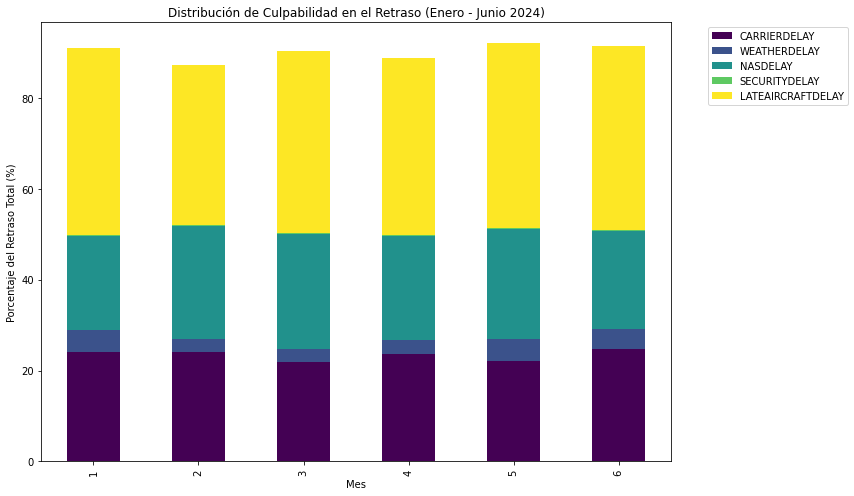

In [25]:
# 1. Definimos la lista de todos los culpables
culpables = ['CARRIERDELAY', 'WEATHERDELAY', 'NASDELAY', 'SECURITYDELAY', 'LATEAIRCRAFTDELAY']

# 2. Calculamos la media de minutos de cada retraso por mes
media_culpables_mes = df_total.groupby('MONTH')[culpables].mean()

# 3. Calculamos el PESO (%) de cada culpable sobre el retraso total
# Solo para vuelos con retraso para evitar distorsiones
vuelos_con_retraso = df_total[df_total['ARRDELAY'] > 0]

def calcular_pesos(group):
    total_minutos = group['ARRDELAY'].sum()
    # Calculamos el % de cada columna sobre ese total
    pesos = (group[culpables].sum() / total_minutos) * 100
    return pesos

pesos_culpables_mes = vuelos_con_retraso.groupby('MONTH').apply(calcular_pesos)

print("📊 MEDIA DE MINUTOS POR CAUSA Y MES:")
print(media_culpables_mes)
print("\n⚖️ PESO RELATIVO (%) DE CADA CAUSA SOBRE EL RETRASO TOTAL:")
print(pesos_culpables_mes)

# 4. OPCIONAL: Visualización rápida (Gráfico de barras apiladas)
pesos_culpables_mes.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Distribución de Culpabilidad en el Retraso (Enero - Junio 2024)')
plt.ylabel('Porcentaje del Retraso Total (%)')
plt.xlabel('Mes')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('analisis_culpables_apilado.png')
plt.show()

In [26]:
# 2. Análisis de relevancia para la quema final
variables_analisis = ['ARRDELAY', 'TAXIIN', 'TAXIOUT', 'AIRTIME', 'DISTANCE', 'CRSELAPSEDTIME','CRSDEPTIME_FORMATO']
correlacion_target = df_total[df_total.columns.intersection(variables_analisis)].corr()['ARRDELAY'].sort_values(ascending=False)

print("📊 CORRELACIÓN OPERATIVA:")
print(correlacion_target)

📊 CORRELACIÓN OPERATIVA:
ARRDELAY          1.000000
TAXIOUT           0.290482
TAXIIN            0.167314
AIRTIME           0.047278
DISTANCE          0.015144
CRSELAPSEDTIME    0.001559
Name: ARRDELAY, dtype: float64


In [27]:
# 3. Borrado final de variables de baja correlación y fecha
final_drop = ['AIRTIME', 'DISTANCE', 'CRSELAPSEDTIME', 'FLIGHTDATE','CRSDEPTIME_FORMATO']
df_total = df_total.drop(columns=final_drop, errors='ignore')

print(f"✅ Dataset purificado. Variables finales eliminadas: {final_drop}")
print(f"🚀 Dimensiones finales del dataset: {df_total.shape}")

✅ Dataset purificado. Variables finales eliminadas: ['AIRTIME', 'DISTANCE', 'CRSELAPSEDTIME', 'FLIGHTDATE', 'CRSDEPTIME_FORMATO']
🚀 Dimensiones finales del dataset: (2354820, 30)


In [28]:
df_total.columns.tolist()

['TAIL_NUMBER',
 'FULL_DATETIME_DEP',
 'ARRDELAY',
 'ARRDEL15',
 'MONTH',
 'DAYOFWEEK',
 'REPORTING_AIRLINE',
 'DEPTIMEBLK',
 'ORIGIN',
 'DEST',
 'DEPDELAY',
 'TAXIOUT',
 'TAXIIN',
 'CARRIERDELAY',
 'WEATHERDELAY',
 'NASDELAY',
 'SECURITYDELAY',
 'LATEAIRCRAFTDELAY',
 'RETRASO_VUELO_ANTERIOR',
 'FEAT_RETRASO_ACUMULADO',
 'TIEMPO_TIERRA_PROG',
 'MARGEN_OPERATIVO_REAL',
 'Rango_de_Retraso',
 'ES_FESTIVO',
 'VUELOS_AEROPUERTO_DIA',
 'FRANJA_HORARIA',
 'RECUPERACION_MINUTOS',
 'MARGEN_CATEGORIA',
 'TIPO_AEROPUERTO',
 'ESTACION']